# Telco Customer Churn — Prediction

See `README.md` for the full write-up, methodology, and findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    precision_recall_curve
)
import shap

RANDOM_STATE = 42
df = pd.read_csv("telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. EDA

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


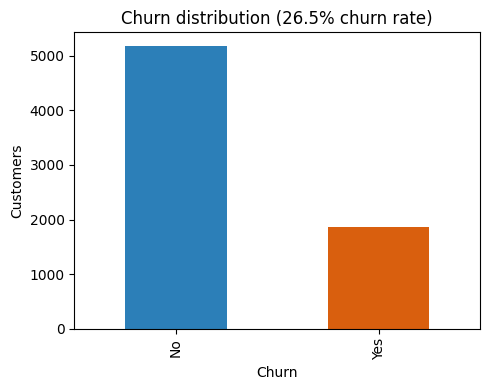

In [2]:
churn_rate = df['Churn'].value_counts(normalize=True)
print(churn_rate)

fig, ax = plt.subplots(figsize=(5,4))
df['Churn'].value_counts().plot(kind='bar', ax=ax, color=['#2c7fb8','#d95f0e'])
ax.set_title('Churn distribution (26.5% churn rate)')
ax.set_ylabel('Customers')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=100)
plt.show()

In [3]:
bad = df[pd.to_numeric(df['TotalCharges'], errors='coerce').isna()]
print(f"{len(bad)} rows fail to convert to numeric")
bad[['customerID','tenure','MonthlyCharges','TotalCharges','Churn']]

11 rows fail to convert to numeric


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [4]:
df = df[pd.to_numeric(df['TotalCharges'], errors='coerce').notna()].copy()
df['TotalCharges'] = df['TotalCharges'].astype(float)
print(f"Rows after cleaning: {len(df)}")

Rows after cleaning: 7032


In [5]:
print("Average tenure by churn status:")
print(df.groupby('Churn')['tenure'].mean())
print()
print("Churn rate by contract type:")
print(df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').mean()))

Average tenure by churn status:
Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

Churn rate by contract type:
Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64


## 2. Feature Engineering

In [6]:
print(df[['tenure','MonthlyCharges','TotalCharges']].corr())

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.246862      0.825880
MonthlyCharges  0.246862        1.000000      0.651065
TotalCharges    0.825880        0.651065      1.000000


In [7]:
df['ExpectedTotal'] = df['tenure'] * df['MonthlyCharges']
df['BillingGap'] = df['TotalCharges'] - df['ExpectedTotal']

print("Correlation of BillingGap with original features:")
print(df[['tenure','MonthlyCharges','TotalCharges','BillingGap']].corr()['BillingGap'])
print()
print("BillingGap by churn status:")
print(df.groupby('Churn')['BillingGap'].describe()[['mean','std','50%']])

Correlation of BillingGap with original features:
tenure            0.012261
MonthlyCharges    0.006785
TotalCharges      0.045570
BillingGap        1.000000
Name: BillingGap, dtype: float64

BillingGap by churn status:
           mean        std  50%
Churn                          
No     0.140858  70.948991  0.0
Yes    0.187266  55.812596  0.0


In [8]:
df = df.drop(columns=['TotalCharges', 'ExpectedTotal', 'BillingGap', 'customerID'])

In [9]:
binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df[col] = (df[col] == "Yes").astype(int)
df["gender"] = (df["gender"] == "Male").astype(int)

target = (df["Churn"] == "Yes").astype(int)
df = df.drop(columns=["Churn"])

multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

X = df
y = target
print(f"Final feature set: {X.shape[1]} columns")
X.head()

Final feature set: 29 columns


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,MultipleLines_No phone service,MultipleLines_Yes,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,True,False,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,False,False,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,True,False,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,False,False,...,False,False,False,False,False,False,False,False,True,False


## 3. Testing and Training data splitting

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 5625 rows | Test: 1407 rows


## 4. Baseline Model — Logistic Regression

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, logreg_proba):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, logreg_proba):.3f}")

ROC-AUC: 0.833
PR-AUC:  0.615


## 5. Random Forest

In [12]:
rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, rf_proba):.3f}")

ROC-AUC: 0.815
PR-AUC:  0.588


## 6. Threshold Tuning (F2-Score)

In [13]:
def best_f2_threshold(y_true, proba):
    precisions, recalls, thresholds = precision_recall_curve(y_true, proba)
    f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-9)
    best_idx = np.argmax(f2_scores[:-1])
    return thresholds[best_idx], f2_scores[best_idx]

print("=" * 55)
print("LOGISTIC REGRESSION")
print("=" * 55)
thresh_lr, f2_lr = best_f2_threshold(y_test, logreg_proba)
print(f"Best F2 threshold: {thresh_lr:.3f} (F2={f2_lr:.3f})")
preds_lr = (logreg_proba >= thresh_lr).astype(int)
print(classification_report(y_test, preds_lr, target_names=["No Churn","Churn"]))

print("=" * 55)
print("RANDOM FOREST")
print("=" * 55)
thresh_rf, f2_rf = best_f2_threshold(y_test, rf_proba)
print(f"Best F2 threshold: {thresh_rf:.3f} (F2={f2_rf:.3f})")
preds_rf = (rf_proba >= thresh_rf).astype(int)
print(classification_report(y_test, preds_rf, target_names=["No Churn","Churn"]))

LOGISTIC REGRESSION
Best F2 threshold: 0.306 (F2=0.744)
              precision    recall  f1-score   support

    No Churn       0.95      0.53      0.68      1033
       Churn       0.42      0.93      0.57       374

    accuracy                           0.63      1407
   macro avg       0.68      0.73      0.63      1407
weighted avg       0.81      0.63      0.65      1407

RANDOM FOREST
Best F2 threshold: 0.167 (F2=0.732)
              precision    recall  f1-score   support

    No Churn       0.93      0.58      0.72      1033
       Churn       0.43      0.89      0.58       374

    accuracy                           0.66      1407
   macro avg       0.68      0.73      0.65      1407
weighted avg       0.80      0.66      0.68      1407



## 7. Explainability (SHAP)

In [14]:
explainer = shap.LinearExplainer(logreg, X_train_scaled)
shap_values = explainer(X_test_scaled)
shap_values.feature_names = list(X.columns)

mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=X.columns
).sort_values(ascending=False)
print("Top 10 features by mean |SHAP value|:")
print(mean_abs_shap.head(10))

Background dataset has 5625 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5625 when initializing the masker.


Top 10 features by mean |SHAP value|:
InternetService_Fiber optic       0.774815
MonthlyCharges                    0.690367
tenure                            0.679818
Contract_Two year                 0.528854
StreamingTV_Yes                   0.278741
StreamingMovies_Yes               0.268389
Contract_One year                 0.263248
MultipleLines_Yes                 0.216849
PaymentMethod_Electronic check    0.189669
PaperlessBilling                  0.121173
dtype: float64


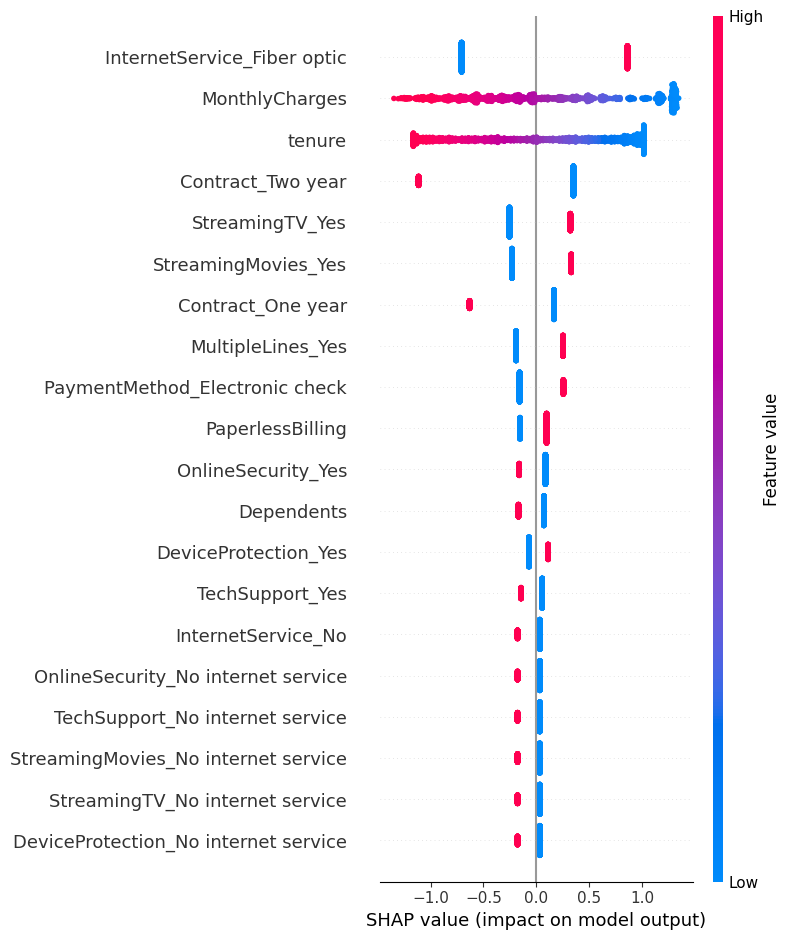

In [15]:
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()